In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, vocab, max_length = 256):
        pass
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx]), torch.tensor(self.labels[idx], dtype=torch.float32)

In [4]:
print("전처리된 데이터 로드 중...")
torch.serialization.add_safe_globals([IMDBDataset])
checkpoint = torch.load("/content/drive/MyDrive/DILAB/YB/attention-paper-experiments/Exp2_IMDBdata_hitmap/preprocessed_data.pt", map_location=device)
train_dataset = checkpoint["train_dataset"]
test_dataset = checkpoint["test_dataset"]
vocab = checkpoint["vocab"]

전처리된 데이터 로드 중...


In [5]:
idx_to_word = {idx: word for word, idx in vocab.items()}
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
class VisualizableTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, max_seq_length=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_embedding = nn.Embedding(max_seq_length, embed_dim)

        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=2, dim_feedforward=embed_dim*2, batch_first=True
        )
        self.fc = nn.Linear(embed_dim, 2)

    def forward(self, x, return_attn=False):
        seq_len = x.size(1)
        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0).expand(x.size(0), -1)
        embedded = self.embedding(x) + self.pos_embedding(positions)

        if return_attn:
            attn_output, attn_weights = self.encoder_layer.self_attn(embedded, embedded, embedded, need_weights=True)
            out = self.fc(attn_output[:, -1, :])
            return out, attn_weights
        else:
            out = self.encoder_layer(embedded)
            last_output = out[:, -1, :]
            return self.fc(last_output)

In [7]:
def train_model(model, dataloader, criterion, optimizer, num_epochs=3):
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        correct = 0
        total = 0
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device).long()

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        acc = 100. * correct / total
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(dataloader):.4f} | Acc: {acc:.2f}%")

In [19]:
def visualize_attention_wrapped(model, dataset, idx_to_word, sample_idx=0, tokens_per_row=15):
    model.eval()

    inputs, label = dataset[sample_idx]
    inputs = inputs.unsqueeze(0).to(device)

    input_list = inputs[0].cpu().numpy()
    actual_length = np.count_nonzero(input_list)
    words = [idx_to_word.get(idx, '<UNK>') for idx in input_list[:actual_length]]

    with torch.no_grad():
        output, attn_weights = model(inputs, return_attn=True)
        _, predicted = output.max(1)

    if attn_weights.dim() == 4:
        attn_map = attn_weights[0].mean(dim=(0, 1)).cpu().numpy()
    else:
        attn_map = attn_weights[0].mean(dim=0).cpu().numpy()

    attn_map = attn_map[:actual_length]

    attn_min = attn_map.min()
    attn_max = attn_map.max()
    attn_map = (attn_map - attn_min) / (attn_max - attn_min + 1e-8)

    num_rows = (actual_length + tokens_per_row - 1) // tokens_per_row
    fig, axes = plt.subplots(num_rows, 1, figsize=(15, 3 * num_rows))

    if num_rows == 1: axes = [axes]

    sentiment = "Positive" if predicted.item() == 1 else "Negative"
    true_sentiment = "Positive" if label.item() == 1 else "Negative"

    for i in range(num_rows):
        start_idx = i * tokens_per_row
        end_idx = min((i + 1) * tokens_per_row, actual_length)

        row_words = words[start_idx:end_idx]
        row_attn = attn_map[start_idx:end_idx].reshape(1, -1)

        sns.heatmap(row_attn, xticklabels=row_words, yticklabels=[f'Line {i+1}'],
                    cmap='magma', cbar=(i==0), ax=axes[i], annot=True, fmt=".2f")
        axes[i].set_xticklabels(row_words, rotation=30, ha='right', fontsize=11)

    plt.suptitle(f"Transformer Attention Map\n[Pred: {sentiment} / True: {true_sentiment}]", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return words, attn_map


--- Transformer 학습 시작 ---
Epoch 1/10 | Loss: 0.6544 | Acc: 59.59%
Epoch 2/10 | Loss: 0.5362 | Acc: 73.02%
Epoch 3/10 | Loss: 0.4016 | Acc: 81.96%
Epoch 4/10 | Loss: 0.3207 | Acc: 86.15%
Epoch 5/10 | Loss: 0.2646 | Acc: 89.09%
Epoch 6/10 | Loss: 0.2244 | Acc: 90.98%
Epoch 7/10 | Loss: 0.1919 | Acc: 92.49%
Epoch 8/10 | Loss: 0.1670 | Acc: 93.46%
Epoch 9/10 | Loss: 0.1517 | Acc: 94.17%
Epoch 10/10 | Loss: 0.1325 | Acc: 94.96%

--- 어텐션 맵 시각화 ---


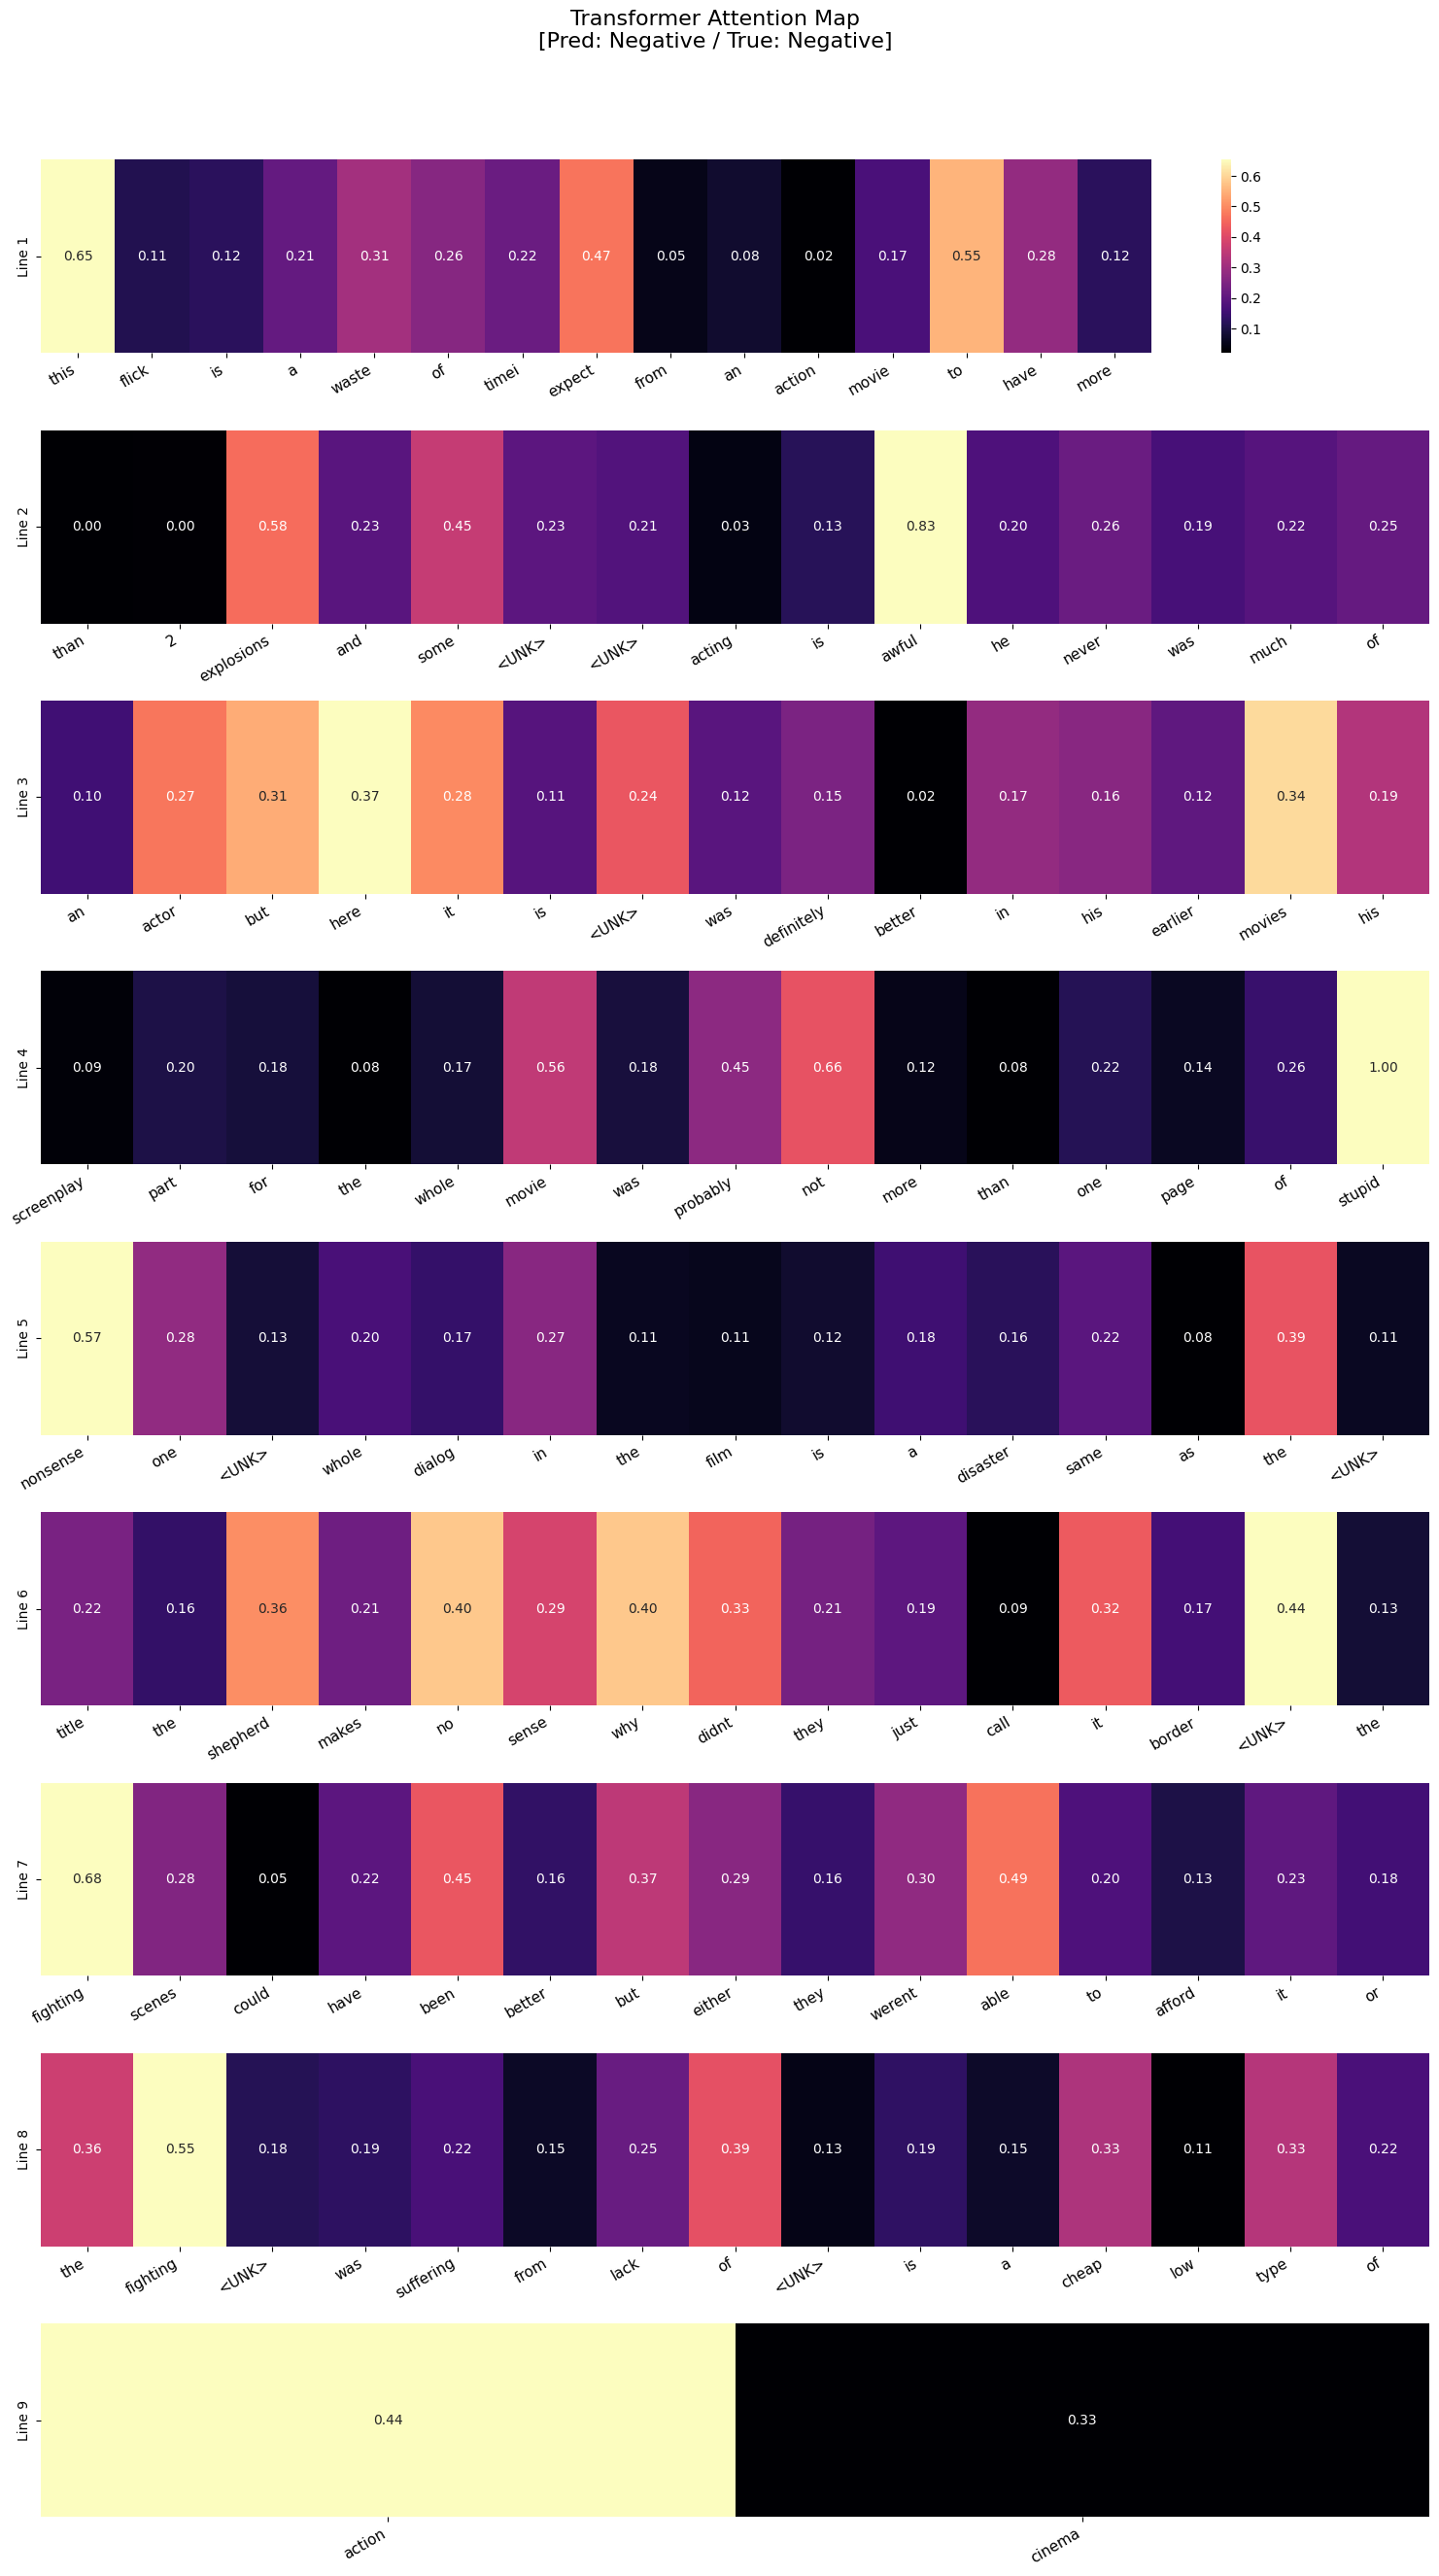

In [20]:
vocab_size = len(vocab)
embed_dim = 64
hidden_dim = 64

print("\n--- Transformer 학습 시작 ---")
tf_model = VisualizableTransformer(vocab_size, embed_dim).to(device)
criterion = nn.CrossEntropyLoss()
tf_optim = optim.Adam(tf_model.parameters(), lr=0.001)

train_model(tf_model, train_loader, criterion, tf_optim, num_epochs=10)

print("\n--- 어텐션 맵 시각화 ---")
words, attn_map = visualize_attention_wrapped(tf_model, test_dataset, idx_to_word, sample_idx=10)

In [21]:
model_save_path = "/content/drive/MyDrive/DILAB/YB/attention-paper-experiments/Exp2_IMDBdata_hitmap/tf_model_weights.pth"
torch.save(tf_model.state_dict(), model_save_path)

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_attention_wordcloud(words, attn_map):
    word_freq = {word: float(score) for word, score in zip(words, attn_map) if word not in ["<UNK>", "<PAD>"]}

    wc = WordCloud(width=800, height=400, background_color="white", colormap="magma")
    wc.generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Attention-based Word Cloud", fontsize=15)
    plt.show()

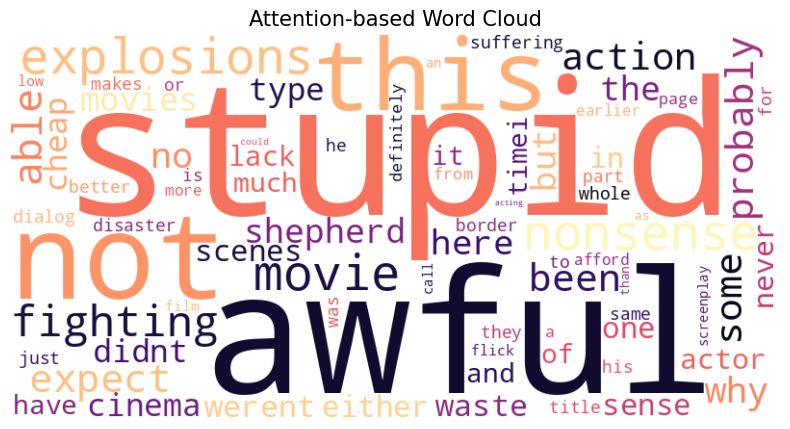

In [23]:
plot_attention_wordcloud(words, attn_map)